# Entropy Control in Generative Modeling

## Theoretical Background

In the context of generative quantum machine learning, evaluating model expressivity requires reference (ground truth) probability distributions with tunable complexity. A fundamental metric for this complexity is the Shannon entropy:

$$H(P) = -\sum_{i=1}^{N} P_i \ln P_i \in [0,\ln N]$$

where $N$ is the dimension of the state space. To generate a distribution $P$ with a specific target entropy $H_{target}$, we adopt the maximum entropy principle under an energy constraint, leading to the **Boltzmann Distribution** (also known as Softmax with temperature).

Given a set of random energy levels $\{E_1, E_2, \dots, E_N\}$, the probability of being in state $i$ is defined as:

$$P_i(\beta) = \frac{e^{-\beta E_i}}{Z(\beta)}, \quad Z(\beta) = \sum_{j=1}^{N} e^{-\beta E_j}$$

Where:
* $E_i$ are "energies" typically drawn from a standard normal distribution $\mathcal{N}(0,1)$.
* $\beta = 1/T$ is the **inverse temperature**, acting as a regulator for the distribution's spread.
* $Z(\beta)$ is the **partition function** ensuring normalization.

## Thermodynamic Monotonicity and Optimization

This approach is particularly useful because the entropy $H(\beta)$ is a **monotonically decreasing function** of the inverse temperature $\beta$:

* **Infinite Temperature ($\beta \to 0$):** The distribution becomes uniform, reaching maximum entropy $H_{max} = \ln N$.
* **Zero Temperature ($\beta \to \infty$):** The distribution concentrates on the ground state (the state with the lowest energy), resulting in $H = 0$.

Since $H(\beta)$ is monotonic, the problem of matching a target entropy is reduced to a **root-finding task**: finding the precise $\beta^*$ such that:

$$f(\beta^*) = H(\beta^*) - H_{target} = 0$$

Using efficient numerical solvers like **Brent's method**, we can identify $\beta^*$ with high precision. This methodology allows us to generate synthetic datasets with controlled correlations and complexity, providing a robust benchmark for IQP circuit optimizations and kernel-based loss functions like MMD.

In [2]:
import jax
import jax.numpy as jnp
from scipy.optimize import brentq

def generate_distribution_with_target_entropy(n_states: int, target_entropy: float, key: jax.Array) -> jnp.ndarray:
    """Generates a discrete probability distribution with a specific target Shannon entropy.

    This function uses a Boltzmann distribution (softmax) over a random energy landscape.
    It solves for the inverse temperature beta such that the resulting distribution 
    matches the requested entropy. This is useful for benchmarking IQP-based 
    generative models under different data complexity regimes.

    Args:
        n_states (int): The number of possible outcomes (size of the Hilbert space 
            or bitstring space).
        target_entropy (float): Desired Shannon entropy in nats. Must be in the 
            range [0, log(n_states)].
        key (jax.Array): A JAX PRNG key used to generate the underlying 
            random energy landscape.

    Returns:
        jnp.ndarray: A 1D array of shape (n_states,) representing the 
            normalized probability distribution.

    Raises:
        ValueError: If target_entropy is greater than the maximum possible 
            entropy for the given n_states.

    Notes:
        The implementation uses Brent's root-finding method to find the optimal 
        inverse temperature. For target_entropy = log(n_states), a uniform 
        distribution is returned directly.
    """
    max_entropy = float(jnp.log(n_states))
    if target_entropy >= max_entropy:
        return jnp.ones(n_states) / n_states
    elif target_entropy <= 0.0:
        dist = jnp.zeros(n_states)
        # Se entropia 0, collassiamo tutto su un singolo stato a caso
        idx = jax.random.randint(key, shape=(), minval=0, maxval=n_states)
        return dist.at[idx].set(1.0)
    
    # Generiamo un panorama di "energie" casuali
    energies = jax.random.normal(key, (n_states,))
    
    # Shift delle energie per stabilità numerica (log-sum-exp trick)
    shifted_energies = energies - jnp.min(energies)
    
    # Funzione per la distribuzione di Boltzmann
    def boltzmann_dist(beta: float) -> jnp.ndarray:
        exp_terms = jnp.exp(-beta * shifted_energies)
        return exp_terms / jnp.sum(exp_terms)
    
    # Funzione obiettivo per il root-finding: S(beta) - target = 0
    def entropy_diff(beta: float) -> float:
        p = boltzmann_dist(beta)
        # Mask per evitare warning su log(0) se beta è molto grande
        p_safe = jnp.where(p > 0, p, 1e-12)
        current_entropy = -jnp.sum(p * jnp.log(p_safe))
        return float(current_entropy - target_entropy)
    
    # Ricerca dello zero: S(beta) decresce da max_entropy (a beta=0) a 0 (a beta=inf)
    # Cerchiamo il beta ottimale nell'intervallo [0, 1000]
    try:
        beta_opt = brentq(entropy_diff, 0.0, 1000.0)
    except ValueError:
        # Se 1000 non basta per raggiungere energie abbastanza fredde, allarghiamo il bound
        beta_opt = brentq(entropy_diff, 0.0, 100000.0)
        
    return boltzmann_dist(beta_opt)

Generated distribution: [1.7243622e-04 3.3361343e-05 7.5850713e-01 1.7823604e-01 6.3051023e-02]
Entropy of the distribution: 0.6931472


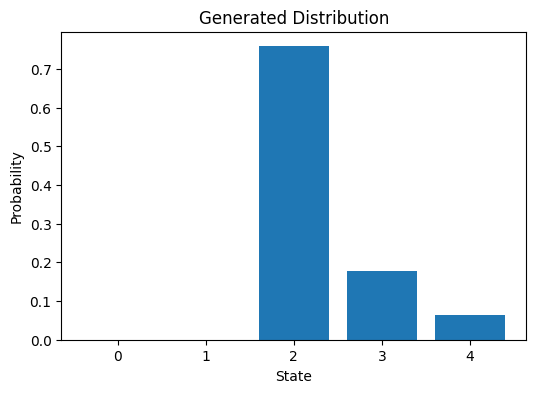

In [13]:
import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)
n_states = 5
target_entropy = jnp.log(2)
distribution = generate_distribution_with_target_entropy(n_states, target_entropy, key)
print("Generated distribution:", distribution)
print("Entropy of the distribution:", -jnp.sum(distribution * jnp.log(distribution + 1e-12)))  # Aggiungiamo un piccolo valore per evitare log(0)


plt.figure(figsize=(6, 4))
plt.bar(range(n_states), distribution)
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("Generated Distribution")
plt.xticks(range(n_states))
plt.show()

In [ ]:
def generate_uniform_entropy_distributions(
    n_dist: int,
    n_qubits: int,
    key: jax.Array,
    *,
    sample_within_bins: bool = True,
):
    """Generate n_dist distributions with entropies uniformly covering [0, log(n_qubits)]."""
    if n_dist <= 0:
        raise ValueError("n_dist must be > 0")
    if n_qubits <= 1:
        raise ValueError("n_qubits must be > 1 to have a non-zero entropy range")

    n_states = 2 ** n_qubits
    h_max = float(jnp.log(n_qubits))

    # Uniform coverage of entropy interval
    if sample_within_bins:
        # Stratified sampling: one target entropy per equal-width bin
        edges = jnp.linspace(0.0, h_max, n_dist + 1)
        k_main, k_ent, k_dist = jax.random.split(key, 3)
        u = jax.random.uniform(k_ent, shape=(n_dist,))
        target_entropies = edges[:-1] + u * (edges[1:] - edges[:-1])
        target_entropies = target_entropies[jax.random.permutation(k_main, n_dist)]
    else:
        # Deterministic uniform grid
        target_entropies = jnp.linspace(0.0, h_max, n_dist)

    keys = jax.random.split(k_dist if sample_within_bins else key, n_dist)
    distributions = jnp.stack(
        [
            generate_distribution_with_target_entropy(n_states, float(h), k)
            for h, k in zip(target_entropies, keys)
        ]
    )
    return distributions, target_entropies

In [22]:
n_dist = 20
n_qubits = 9
key = jax.random.PRNGKey(42)
distributions, target_entropies = generate_uniform_entropy_distributions(n_dist, n_qubits, key, sample_within_bins=False)